In [64]:
import numpy as np
from scipy.constants import g
from scipy.special import ellipk
import matplotlib.pyplot as plt

In [65]:
l = 1.0
theta0_deg = 45

# a)

In [66]:
def solve_pendulum(theta0_deg, length=1.0, n_nodes=10):  
    theta0_rad = np.radians(theta0_deg)
    
    k = np.sin(theta0_rad / 2.0)
    
    def f(theta):
        return 1.0 / np.sqrt(1.0 - k**2 * np.sin(theta)**2)
    
    legendre_nodes, weights = np.polynomial.legendre.leggauss(n_nodes)
    
    a = 0.0
    b = np.pi / 2.0
    
    theta_mapped = 0.5 * (b - a) * legendre_nodes + 0.5 * (a + b)
    
    K_k = 0.5 * (b - a) * np.sum(weights * f(theta_mapped))
    
    T_exact = 4.0 * np.sqrt(length / g) * K_k
    
    T_approx = 2.0 * np.pi * np.sqrt(length / g)
    
    relative_error = abs(T_exact - T_approx) / T_exact * 100.0
    
    return k, K_k, T_exact, T_approx, relative_error

In [67]:
k_val, K_val, T_exact, T_approx, error = solve_pendulum(theta0_deg)

In [68]:
print(f"--- Results for theta0 angle: {theta0_deg} degrees ---")
print(f"Modulus k:              {k_val:.4f}")
print(f"Elliptic integral K(k): {K_val:.4f}")
print(f"Exact period T:         {T_exact:.4f} s")
print(f"Approximate period T_0: {T_approx:.4f} s")
print(f"Relative error:         {error:.2f} %")

--- Results for theta0 angle: 45 degrees ---
Modulus k:              0.3827
Elliptic integral K(k): 1.6336
Exact period T:         2.0866 s
Approximate period T_0: 2.0064 s
Relative error:         3.84 %


# b)

In [69]:
theta0_rad = np.radians(theta0_deg)
k = np.sin(theta0_rad / 2.0)

In [70]:
# scipy.special.ellipk takes the parameter m = k^2 as an argument, not k!
K_true = ellipk(k**2)
T_true = 4.0 * np.sqrt(l / g) * K_true

In [71]:
print(f"--- Results for initial angle: {theta0_deg} degrees ---")
print(f"Modulus k:                  {k:.6f}")
print(f"Exact value K (scipy):      {K_true:.12f}")
print(f"Exact period T:             {T_true:.6f} s\n")
print("--- AGM Iteration Process ---")

--- Results for initial angle: 45 degrees ---
Modulus k:                  0.382683
Exact value K (scipy):      1.633586307458
Exact period T:             2.086612 s

--- AGM Iteration Process ---


In [72]:
a = 1.0 + k
b = 1.0 - k
max_iter = 6
n_values = np.arange(max_iter)
errors = []

In [73]:
for i in range(max_iter):
    K_approx = (np.pi / 2.0) * (1.0 / a)
    
    error = abs(K_approx - K_true) / K_true
    errors.append(error)
    
    print(f"Iteration n = {i}: K_approx = {K_approx:.12f} | relative error = {error:.2e}")
    
    a_next = (a + b) / 2.0
    b_next = np.sqrt(a * b)
    
    a = a_next
    b = b_next

Iteration n = 0: K_approx = 1.136049141855 | relative error = 3.05e-01
Iteration n = 1: K_approx = 1.570796326795 | relative error = 3.84e-02
Iteration n = 2: K_approx = 1.632946658302 | relative error = 3.92e-04
Iteration n = 3: K_approx = 1.633586244806 | relative error = 3.84e-08
Iteration n = 4: K_approx = 1.633586307458 | relative error = 4.08e-16
Iteration n = 5: K_approx = 1.633586307458 | relative error = 0.00e+00


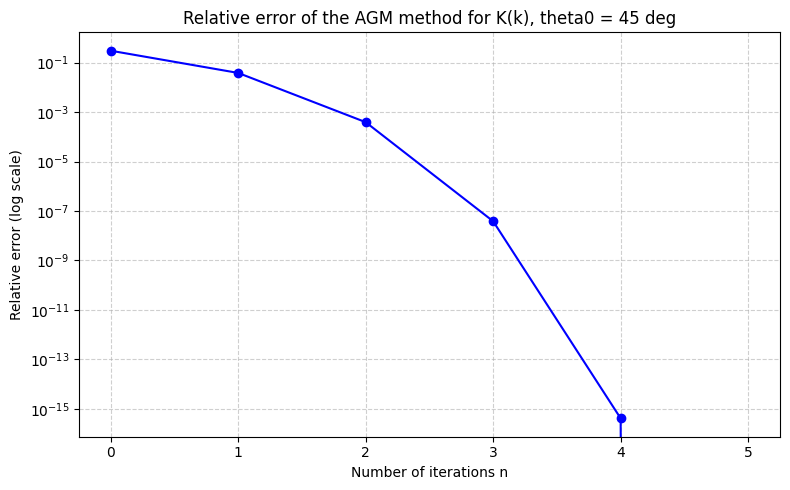

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(n_values, errors, marker='o', linestyle='-', color='b')

plt.yscale('log')
plt.xlabel('Number of iterations n')
plt.ylabel('Relative error (log scale)')
plt.title(f'Relative error of the AGM method for K(k), theta0 = {theta0_deg} deg')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.xticks(n_values)

plt.tight_layout()
plt.show()

In [ ]:
theta0_deg = np.arange(0, 95, 5)

theta0_rad = np.radians(theta0_deg)
k = np.sin(theta0_rad / 2.0)

K_true = ellipk(k**2)

# Error = 1 - (pi / (2 * K(k)))
relative_error_percent = (1.0 - (np.pi / (2.0 * K_true))) * 100.0


In [76]:
print("Angle [deg] | Relative Error [%]")
print("-" * 32)
for angle, error in zip(theta0_deg, relative_error_percent):
    print(f"{angle:11.1f} | {error:16.4f}")

Angle [deg] | Relative Error [%]
--------------------------------
        0.0 |           0.0000
        5.0 |           0.0476
       10.0 |           0.1904
       15.0 |           0.4282
       20.0 |           0.7611
       25.0 |           1.1888
       30.0 |           1.7111
       35.0 |           2.3279
       40.0 |           3.0388
       45.0 |           3.8437
       50.0 |           4.7422
       55.0 |           5.7341
       60.0 |           6.8192
       65.0 |           7.9971
       70.0 |           9.2678
       75.0 |          10.6312
       80.0 |          12.0873
       85.0 |          13.6364
       90.0 |          15.2787


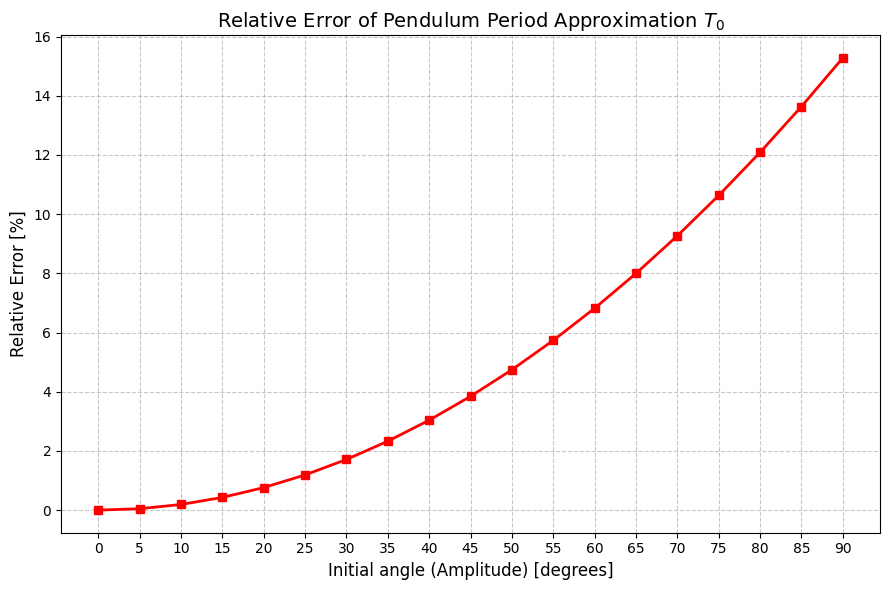

In [77]:
plt.figure(figsize=(9, 6))
plt.plot(theta0_deg, relative_error_percent, marker='s', linestyle='-', color='r', linewidth=2)

plt.xlabel('Initial angle (Amplitude) [degrees]', fontsize=12)
plt.ylabel('Relative Error [%]', fontsize=12)
plt.title('Relative Error of Pendulum Period Approximation $T_0$', fontsize=14)

plt.xticks(np.arange(0, 95, 5))
plt.grid(True, which="both", ls="--", alpha=0.7)

plt.tight_layout()
plt.show()